# Diferencias finitas: flujo inducido por presión

En un fluido real, la velocidad y la presión forman campos continuos: en cada
posición pueden cambiar y esas variaciones están relacionadas por las ecuaciones
de Navier–Stokes. El reto aparece cuando queremos pedirle a una computadora que
resuelva una ecuación diferencial.

Una computadora trabaja con un número finito de valores. Por eso tendremos que
responder, paso a paso, una pregunta concreta:

> ¿Cómo reemplazamos las derivadas de un campo continuo por operaciones entre
> valores almacenados en una malla?

Usaremos diferencias finitas para construir esa traducción. El ejemplo será un
flujo sencillo entre dos placas, pero la idea quedará preparada para problemas
con geometrías y condiciones más complicadas.

**Al final podremos** pasar de una ecuación diferencial a una ecuación para cada
nodo, imponer sus fronteras, iterar una solución y comprobarla contra una
referencia analítica.

## ¿Cómo pasamos de Navier–Stokes a una solución numérica?

La ecuación de cantidad de movimiento para un fluido newtoniano puede escribirse
de forma compacta como

$$
\frac{\partial\vec v}{\partial t}
+(\vec v\cdot\nabla)\vec v
=-\frac{1}{\rho}\nabla p+\nu\nabla^2\vec v+\vec f.
$$

Para un fluido incompresible también debe cumplirse

$$
\nabla\cdot\vec v=0.
$$

Aquí aparecen varias dificultades a la vez: advección, difusión viscosa, presión,
varias componentes de velocidad y condiciones de frontera. No las resolveremos
todas simultáneamente. Primero aislaremos la idea fundamental: representar un
campo en nodos y convertir cada derivada en una relación entre nodos vecinos.

## Un ejemplo sencillo para verlo

Consideraremos un flujo entre dos placas paralelas impulsado por una diferencia
de presión. Es un caso suficientemente simple para obtener una solución
analítica, pero contiene la cadena completa del método:

1. plantear el problema físico;
2. simplificar Navier–Stokes y obtener una ecuación diferencial;
3. aproximar las derivadas en una malla;
4. convertir la ecuación en una propuesta para cada nodo;
5. imponer las fronteras y repetir hasta reducir el residuo;
6. comparar la solución numérica con el perfil de Poiseuille.

La referencia analítica nos permitirá separar dos preguntas: si el algoritmo
converge para la ecuación discretizada y si esa ecuación representa bien el
fenómeno físico.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


## 1. El problema físico: un canal entre dos placas

Concretemos el escenario. Consideremos un canal de longitud $L$ y altura
$H=2a$. El fluido es newtoniano e incompresible, circula principalmente en la
dirección $x$ y las placas permanecen quietas.

Usaremos $\vec v=(v_x,v_y)$ y supondremos que no hay fuerzas de cuerpo
apreciables. La ecuación de cantidad de movimiento es

$$
\frac{\partial\vec v}{\partial t}
+(\vec v\cdot\nabla)\vec v
=-\frac{1}{\rho}\nabla p+\nu\nabla^2\vec v.
$$

La presión es mayor a la izquierda y menor a la derecha, de modo que
$\partial p/\partial x<0$. Buscaremos el campo de velocidad que produce ese
gradiente y que, además, cumple el no deslizamiento en las dos placas.

### ¿Qué estamos buscando?

Todavía no calculamos valores en una malla. Primero fijamos el objetivo físico:
encontrar $v_x(x,y)$ de manera que satisfaga la ecuación reducida y las
condiciones de las placas,

$$
\nu\nabla^2v_x=\frac{1}{\rho}\frac{\partial p}{\partial x},
\qquad
v_x=0\ \text{en las placas}.
$$

La siguiente figura resume la traducción que construiremos: un campo continuo
se observa en nodos y, alrededor de un nodo interior, la ecuación usa sus cuatro
vecinos.

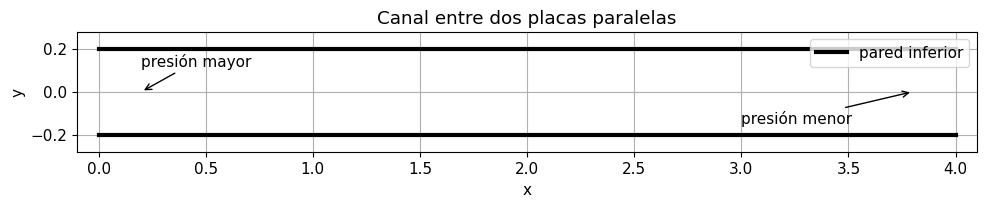

In [2]:
# Fijamos la geometría para que las siguientes figuras compartan ejes.
L = 4.0
a = 0.2
H = 2 * a

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(
    [0, L],
    [-a, -a],
    color="black",
    linewidth=3,
    label="pared inferior",
)
ax.plot([0, L], [a, a], color="black", linewidth=3)
ax.annotate(
    "presión mayor",
    xy=(0.2, 0.0),
    xytext=(0.2, 0.12),
    arrowprops={"arrowstyle": "->"},
)
ax.annotate(
    "presión menor",
    xy=(L - 0.2, 0.0),
    xytext=(L - 1.0, -0.15),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    xlim=(-0.1, L + 0.1),
    ylim=(-a - 0.08, a + 0.08),
    xlabel="x",
    ylabel="y",
    title="Canal entre dos placas paralelas",
)
ax.set_aspect("equal")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 2. ¿Qué podemos simplificar sin perder el fenómeno?

Para obtener un primer problema que podamos seguir de principio a fin,
consideraremos un flujo completamente desarrollado:

$$
v_x=v_x(y),\qquad v_y=0,\qquad p=p(x).
$$

Estas hipótesis significan que el perfil no cambia al avanzar en $x$, no hay
velocidad transversal y la presión solo varía a lo largo del canal. Por tanto,
$\partial v_x/\partial x=0$ y el término convectivo desaparece. La presión
impulsa el flujo y la difusión viscosa se opone a esa variación:

$$
0=-\frac{1}{\rho}\frac{\partial p}{\partial x}
  +\nu\frac{\mathrm d^2v_x}{\mathrm dy^2}.
$$

En las placas imponemos no deslizamiento:

$$
v_x(-a)=0,\qquad v_x(a)=0.
$$

### Una solución conocida para comparar

Este caso todavía tiene una solución analítica. La usaremos como una regla de
comparación durante todo el cálculo:

1. un residuo pequeño indica que la ecuación discretizada se satisface;
2. un error pequeño frente a Poiseuille indica que la discretización y las
   fronteras representan correctamente este caso físico.

Convergencia numérica y fidelidad física son comprobaciones relacionadas, pero
no son la misma.

In [3]:
# Propiedades del fluido y del canal.
rho = 1260.0          # kg/m^3, valor ilustrativo para glicerina
nu = 1.0e-3           # m^2/s, viscosidad cinemática
mu = rho * nu         # Pa s, viscosidad dinámica
U_media = 0.1         # m/s, velocidad media de referencia

# Para una semialtura a:
# U_media = -(dp/dx) * a**2 / (3 * mu).
dp_dx = -3.0 * mu * U_media / a**2

print(f"rho = {rho:.1f} kg/m^3")
print(f"nu  = {nu:.2e} m^2/s")
print(f"mu  = {mu:.3f} Pa s")
print(f"dp/dx = {dp_dx:.3f} Pa/m")

rho = 1260.0 kg/m^3
nu  = 1.00e-03 m^2/s
mu  = 1.260 Pa s
dp/dx = -9.450 Pa/m


Al integrar dos veces y aplicar el no deslizamiento obtenemos el
perfil parabólico de Poiseuille:

$$
v_x(y)=\frac{1}{2\rho\nu}\frac{\partial p}{\partial x}
       \left(y^2-a^2\right).
$$

Como $\partial p/\partial x<0$ y $y^2-a^2\leq 0$, la velocidad es positiva en
el interior. La solución numérica no debe competir con esta fórmula: debe
aproximarla y permitirnos medir cuánto error introduce la malla.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


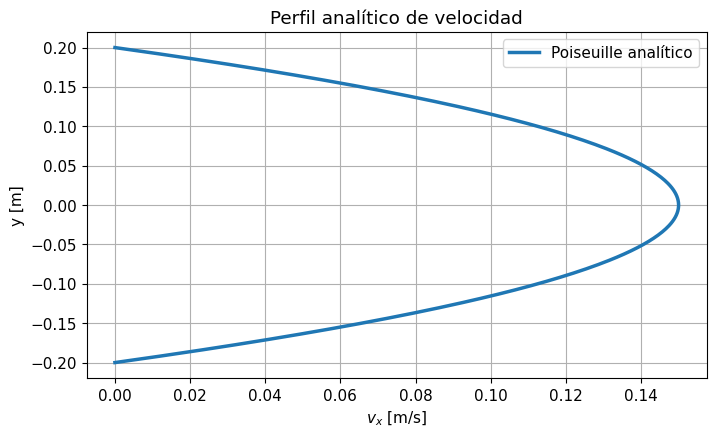

Velocidad media analítica: 0.1000 m/s
Velocidad máxima analítica: 0.1500 m/s


In [4]:
y_analitico = np.linspace(-a, a, 300)
vx_analitico = (dp_dx / (2 * rho * nu)) * (y_analitico**2 - a**2)

fig, ax = plt.subplots()
ax.plot(vx_analitico, y_analitico, linewidth=2.5,
        label="Poiseuille analítico")
ax.set(xlabel=r"$v_x$ [m/s]", ylabel="y [m]",
       title="Perfil analítico de velocidad")
ax.legend()
plt.show()

velocidad_media = np.trapz(vx_analitico, y_analitico) / H
print(f"Velocidad media analítica: {velocidad_media:.4f} m/s")
print(f"Velocidad máxima analítica: {vx_analitico.max():.4f} m/s")


## 3. ¿Cómo pasamos del campo continuo a una malla?

El perfil anterior es posible porque elegimos un problema muy simétrico. Con
obstáculos, entradas no uniformes, geometrías irregulares o advección
importante, las hipótesis $v_x=v_x(y)$ y $v_y=0$ dejan de ser válidas.

La idea de diferencias finitas es representar el campo continuo con valores en
nodos:

$$
v_x(x_i,y_j)\;\longrightarrow\;v^x_{i,j}.
$$

La ecuación diferencial dejará de ser una afirmación sobre todos los puntos del
canal y se convertirá en una colección de relaciones algebraicas entre esos
valores.

### ¿Cómo guardamos el campo en la malla?

Hasta aquí $v_x$ era una función. A partir de la malla, `VX[i, j]` será el valor
almacenado en un nodo concreto. El primer índice $i$ recorre $x$ y el segundo
índice $j$ recorre $y$. El método no intenta guardar infinitos puntos:
elige una cantidad finita de nodos y aproxima las derivadas con la información
local de sus vecinos.

In [5]:
# Cada entrada de VX representará la velocidad en un nodo (i, j).
Nx = 61
Ny = 21
xs = np.linspace(0.0, L, Nx)
ys = np.linspace(-a, a, Ny)
dx = xs[1] - xs[0]
dy = ys[1] - ys[0]
X, Y = np.meshgrid(xs, ys, indexing="ij")

print(f"Malla: {Nx} x {Ny} nodos")
print(f"dx = {dx:.4f} m, dy = {dy:.4f} m")

Malla: 61 x 21 nodos
dx = 0.0667 m, dy = 0.0200 m


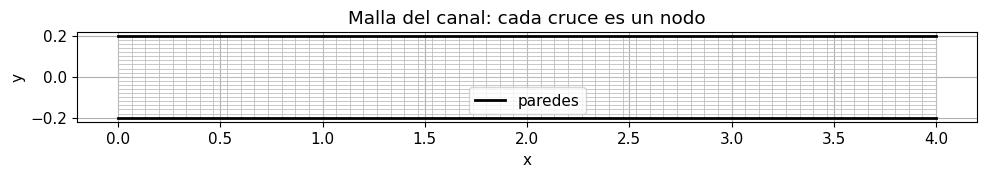

In [6]:
# Dibujamos todos los elementos de la malla para ver qué se discretiza.
fig, ax = plt.subplots(figsize=(10, 3))

for x in xs:
    ax.plot([x, x], [-a, a], color="0.75", linewidth=0.6)

for y in ys:
    ax.plot([0, L], [y, y], color="0.75", linewidth=0.6)

ax.plot([0, L], [-a, -a], color="black", linewidth=2, label="paredes")
ax.plot([0, L], [a, a], color="black", linewidth=2)
ax.set(
    xlabel="x",
    ylabel="y",
    title="Malla del canal: cada cruce es un nodo",
)
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
plt.show()

## 4. ¿Cómo convertimos derivadas en diferencias finitas?

La expansión de Taylor permite sustituir una derivada por diferencias entre
valores vecinos. Para una función $f$ en una malla regular:

$$
\left.\frac{\mathrm df}{\mathrm dx}\right|_i
\approx \frac{f_{i+1}-f_i}{\Delta x}
\quad\text{(hacia adelante)},
$$

$$
\left.\frac{\mathrm df}{\mathrm dx}\right|_i
\approx \frac{f_i-f_{i-1}}{\Delta x}
\quad\text{(hacia atrás)},
$$

$$
\left.\frac{\mathrm df}{\mathrm dx}\right|_i
\approx \frac{f_{i+1}-f_{i-1}}{2\Delta x}
\quad\text{(centrada)}.
$$

La fórmula centrada usa información a ambos lados del nodo y, en una malla
regular, suele tener error de orden $\mathcal O(\Delta x^2)$. Antes de usarla en
Navier–Stokes, comprobaremos esa afirmación con una función conocida.

### ¿Cómo se relacionan los nodos?

Antes de comprobar las fórmulas con una función conocida, resumamos qué significa discretizar una ecuación. El campo continuo se sustituye por valores almacenados en nodos de una malla. En un nodo interior, las derivadas se aproximan usando los valores de los nodos vecinos.

La figura es un mapa conceptual: muestra cómo una ecuación que vale en todo el canal termina convirtiéndose en una relación local entre valores del arreglo.


<img src="source/DF_malla_continua_nodos.png" alt="Del canal continuo a la malla y a la ecuación en un nodo interior" width="900">

### Una prueba pequeña antes de resolver el flujo

Para $f(x)=\sin x$ conocemos exactamente $f'(x)=\cos x$ y
$f''(x)=-\sin x$. Así podemos calcular el error de cada fórmula, en lugar de
aceptarla solo porque aparece escrita en un libro.

In [7]:
def derivada_adelante(f, h):
    """Aproxima f' usando el nodo actual y el siguiente."""
    return (f[1:] - f[:-1]) / h


def derivada_atras(f, h):
    """Aproxima f' usando el nodo actual y el anterior."""
    return (f[1:] - f[:-1]) / h


def derivada_centrada(f, h):
    """Aproxima f' usando un vecino a cada lado del nodo."""
    return (f[2:] - f[:-2]) / (2 * h)


x_prueba = np.linspace(0, 2 * np.pi, 41)
h_prueba = x_prueba[1] - x_prueba[0]
f_prueba = np.sin(x_prueba)

error_adelante = np.max(
    np.abs(derivada_adelante(f_prueba, h_prueba) - np.cos(x_prueba[:-1]))
)
error_atras = np.max(
    np.abs(derivada_atras(f_prueba, h_prueba) - np.cos(x_prueba[1:]))
)
error_centrada = np.max(
    np.abs(derivada_centrada(f_prueba, h_prueba) - np.cos(x_prueba[1:-1]))
)

print(f"Error máximo hacia adelante: {error_adelante:.3e}")
print(f"Error máximo hacia atrás:    {error_atras:.3e}")
print(f"Error máximo centrada:        {error_centrada:.3e}")

Error máximo hacia adelante: 7.838e-02
Error máximo hacia atrás:    7.838e-02
Error máximo centrada:        4.107e-03


La segunda derivada se obtiene combinando dos diferencias
centradas:

$$
\left.\frac{\mathrm d^2f}{\mathrm dx^2}\right|_i
\approx
\frac{f_{i+1}-2f_i+f_{i-1}}{\Delta x^2}.
$$

En dos dimensiones aplicamos la misma idea en cada dirección. Para un nodo
interior,

$$
\nabla^2 v^x_{i,j}\approx
\frac{v^x_{i+1,j}-2v^x_{i,j}+v^x_{i-1,j}}{\Delta x^2}
+
\frac{v^x_{i,j+1}-2v^x_{i,j}+v^x_{i,j-1}}{\Delta y^2}.
$$

In [8]:
def segunda_derivada_centrada(f, h):
    """Aproxima f'' con el valor central y sus dos vecinos."""
    return (f[2:] - 2 * f[1:-1] + f[:-2]) / h**2


segunda_numerica = segunda_derivada_centrada(f_prueba, h_prueba)
segunda_exacta = -np.sin(x_prueba[1:-1])
error_segunda = np.max(np.abs(segunda_numerica - segunda_exacta))
print(f"Error máximo para la segunda derivada: {error_segunda:.3e}")

Error máximo para la segunda derivada: 2.054e-03


### Reto 1 — comprobar el orden del error

Construye varias mallas para $f(x)=\sin x$ y registra el error de la segunda
derivada centrada. Si al reducir $h$ a la mitad el error disminuye
aproximadamente cuatro veces, el comportamiento es compatible con
$\mathcal O(h^2)$.

Intenta escribir y ejecutar la celda. La respuesta sugerida queda más abajo,
dentro de un desplegable.

<details>
<summary>Respuesta sugerida del Reto 1</summary>

Al reducir $h$ a la mitad, el error debería disminuir aproximadamente
por un factor de cuatro. Esta es una comprobación computacional del orden
$\mathcal O(h^2)$.

```python
errores = []
pasos = [0.4, 0.2, 0.1, 0.05]

for h in pasos:
    x = np.arange(0, 2 * np.pi + h, h)
    f = np.sin(x)
    error = np.max(
        np.abs(segunda_derivada_centrada(f, h) + np.sin(x[1:-1]))
    )
    errores.append(error)

for h, error in zip(pasos, errores):
    print(f"h = {h:.3f} -> error = {error:.3e}")
```
</details>

## 5. ¿Qué debe cumplirse en cada nodo?

Para el flujo de Poiseuille, la ecuación reducida es

$$
\nu\left(\frac{\partial^2 v_x}{\partial x^2}
       +\frac{\partial^2 v_x}{\partial y^2}\right)
=\frac{1}{\rho}\frac{\partial p}{\partial x}.
$$

Dividimos por $\nu$ y definimos la fuente constante

$$
S=\frac{1}{\rho\nu}\frac{\partial p}{\partial x}.
$$

Al sustituir las diferencias centradas obtenemos una ecuación para cada nodo
interior:

$$
\frac{v^x_{i+1,j}-2v^x_{i,j}+v^x_{i-1,j}}{\Delta x^2}
+\frac{v^x_{i,j+1}-2v^x_{i,j}+v^x_{i,j-1}}{\Delta y^2}=S.
$$

Despejamos el valor central. La estrella significa que todavía es una
**propuesta**, no la solución completa:

$$
v^{x,\star}_{i,j}=
\frac{\displaystyle
\frac{v^x_{i+1,j}+v^x_{i-1,j}}{\Delta x^2}
+\frac{v^x_{i,j+1}+v^x_{i,j-1}}{\Delta y^2}-S}
{\displaystyle\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}}.
$$

### Primero entendamos un solo nodo

Los cuatro vecinos también son incógnitas. Por eso el cálculo de un nodo no
resuelve el canal de una vez: propone un valor, lo incorpora al campo y luego
vuelve a medir el desequilibrio.

Primero veremos esa operación en un único nodo interior. Así la función
`valor_propuesto` deja de ser una fórmula aislada y se convierte en un paso
concreto del algoritmo.

In [9]:
S = dp_dx / (rho * nu)


def valor_propuesto(U, i, j, dx, dy, S):
    """Propone la velocidad de un nodo usando sus cuatro vecinos.

    La función traduce la ecuación discretizada del nodo (i, j). No resuelve
    toda la malla: solo responde qué valor tendría sentido probar aquí.
    """
    peso_x = 1.0 / dx**2
    peso_y = 1.0 / dy**2
    numerador = (
        peso_x * (U[i + 1, j] + U[i - 1, j])
        + peso_y * (U[i, j + 1] + U[i, j - 1])
        - S
    )
    denominador = 2 * peso_x + 2 * peso_y
    return numerador / denominador


def residuo_en_nodo(U, i, j, dx, dy, S):
    """Mide el desequilibrio de la ecuación en un nodo interior."""
    laplaciano = (
        (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j]) / dx**2
        + (U[i, j + 1] - 2 * U[i, j] + U[i, j - 1]) / dy**2
    )
    return laplaciano - S


i_demo = Nx // 2
j_demo = Ny // 2
U_demo = np.zeros((Nx, Ny))
propuesta = valor_propuesto(U_demo, i_demo, j_demo, dx, dy, S)
residuo_antes = residuo_en_nodo(U_demo, i_demo, j_demo, dx, dy, S)

# Aceptamos solo la mitad de la propuesta para ver el efecto de la relajación.
omega_demo = 0.5
U_demo[i_demo, j_demo] += omega_demo * (propuesta - U_demo[i_demo, j_demo])
residuo_despues = residuo_en_nodo(U_demo, i_demo, j_demo, dx, dy, S)

print(f"nodo elegido: (i, j) = ({i_demo}, {j_demo})")
print(f"fuente S = {S:.3e} 1/(m s)")
print(f"propuesta central = {propuesta:.3e} m/s")
print(f"residuo antes = {residuo_antes:.3e}")
print(f"residuo después = {residuo_despues:.3e}")

nodo elegido: (i, j) = (30, 10)
fuente S = -7.500e+00 1/(m s)
propuesta central = 1.376e-03 m/s
residuo antes = 7.500e+00
residuo después = 3.750e+00


### Qué ocurrió en ese nodo

Partimos de un campo nulo, así que la ecuación no estaba satisfecha: el residuo
era distinto de cero. La propuesta usa la presión aplicada y los cuatro vecinos;
al aceptar solo una fracción de ella, el residuo disminuye. El barrido posterior
repite exactamente esta operación en todos los nodos interiores.

## 6. ¿Qué ocurre en las fronteras?

La ecuación diferencial interior no determina por sí sola un campo único. Hay
que decir qué ocurre en los bordes del dominio.

### Paredes sólidas: condición de Dirichlet

En las placas imponemos no deslizamiento:

$$
v_x(x,-a)=0,\qquad v_x(x,a)=0.
$$

Aquí conocemos directamente el valor del campo.

### Extremos del canal: condición de Neumann

Como representamos un flujo ya desarrollado, pedimos que el perfil no cambie en
la dirección $x$:

$$
\frac{\partial v_x}{\partial x}=0
\qquad\text{en }x=0\text{ y }x=L.
$$

En el extremo izquierdo, por ejemplo,

$$
\frac{v^x_{1,j}-v^x_{0,j}}{\Delta x}=0
\quad\Longrightarrow\quad
v^x_{0,j}=v^x_{1,j}.
$$

Por eso el código copia el nodo vecino en los extremos de $x$. No está
prescribiendo una velocidad de entrada: está imponiendo una derivada normal
nula.

### ¿Por qué imponemos las fronteras otra vez?

Después de actualizar los nodos interiores, aplicamos de nuevo las dos clases
de condiciones:

- en las placas, fijamos el valor $v_x=0$;
- en los extremos, igualamos el nodo de frontera con su vecino para conservar
  $\partial v_x/\partial x=0$.

Si omitiéramos este paso, los valores de la frontera podrían cambiar y el
algoritmo terminaría resolviendo otro problema.

In [10]:
def imponer_fronteras(U):
    """Aplica las condiciones de las placas y de los extremos del canal."""
    # Gradiente normal nulo en los extremos x = 0 y x = L.
    U[0, :] = U[1, :]
    U[-1, :] = U[-2, :]

    # No deslizamiento en las placas y = -a y y = a.
    U[:, 0] = 0.0
    U[:, -1] = 0.0
    return U


U_prueba = np.ones((Nx, Ny))
imponer_fronteras(U_prueba)
print("pared inferior:", np.unique(U_prueba[:, 0]))
print("pared superior:", np.unique(U_prueba[:, -1]))

pared inferior: [0.]
pared superior: [0.]


## 7. ¿Cómo construimos la solución paso a paso?

Un nodo depende de sus vecinos, pero esos vecinos también son desconocidos. La
solución se construye recorriendo la malla y actualizando el campo muchas veces.

Si $v^{x,\star}_{i,j}$ es la propuesta local, usamos

$$
v^{x,(k+1)}_{i,j}
=v^{x,(k)}_{i,j}
+\omega\left(v^{x,\star}_{i,j}-v^{x,(k)}_{i,j}\right).
$$

$\omega$ no es un paso de tiempo físico:

- $\omega=1$ acepta la propuesta completa;
- $0<\omega<1$ avanza con más cautela;
- un valor mayor que uno puede acelerar, pero también producir oscilaciones.

### ¿Qué hacemos en cada iteración?

En cada iteración hacemos exactamente esto:

1. tomamos el campo actual;
2. calculamos una propuesta para cada nodo interior;
3. aceptamos una fracción $\omega$ de cada corrección;
4. volvemos a imponer las fronteras;
5. medimos el residuo;
6. detenemos el ciclo si el residuo está por debajo de la tolerancia.

El residuo será nuestra medida de cuánto falta para satisfacer la ecuación
discretizada.

In [11]:
def residuo_poisson(U, dx, dy, S):
    """Evalúa el desequilibrio de Poisson en todos los nodos interiores."""
    laplaciano = (
        (U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]) / dx**2
        + (U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]) / dy**2
    )
    return laplaciano - S


def resolver_canal(
    Nx,
    Ny,
    L,
    a,
    S,
    omega=1.0,
    tolerancia=1e-6,
    max_iter=8000,
):
    """Resuelve el perfil del canal mediante relajación explícita.

    La función recorre los nodos interiores, aplica la propuesta local y mide
    el residuo después de cada barrido. Devuelve la malla, el campo calculado
    y la historia de convergencia para poder interpretar el resultado.
    """
    xs = np.linspace(0.0, L, Nx)
    ys = np.linspace(-a, a, Ny)
    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    U = np.zeros((Nx, Ny))
    historia = []

    for iteracion in range(max_iter):
        # Cada barrido propone una corrección para todos los nodos interiores.
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                propuesta = valor_propuesto(U, i, j, dx, dy, S)
                U[i, j] += omega * (propuesta - U[i, j])

        imponer_fronteras(U)
        residuo = residuo_poisson(U, dx, dy, S)
        escala = max(abs(S), 1.0)
        chi = np.max(np.abs(residuo)) / escala
        historia.append(chi)

        if chi < tolerancia:
            break

    return xs, ys, U, np.array(historia)

El algoritmo completo ya puede leerse como una traducción directa
de la ecuación:

1. recorremos los nodos interiores con `for`;
2. proponemos un valor usando los cuatro vecinos;
3. aplicamos la relajación;
4. reimponemos las fronteras;
5. calculamos $\chi$;
6. detenemos el proceso si $\chi$ es menor que la tolerancia.

$\chi$ no es una magnitud física. Es una medida numérica del desequilibrio que
queda en la ecuación discretizada.

In [12]:
# Resolvemos el caso base con una tolerancia explícita.
omega_base = 1.0
tolerancia = 1e-6

xs_num, ys_num, VX, historia = resolver_canal(
    Nx=Nx,
    Ny=Ny,
    L=L,
    a=a,
    S=S,
    omega=omega_base,
    tolerancia=tolerancia,
    max_iter=8000,
)

print(f"Iteraciones realizadas: {len(historia)}")
print(f"Residuo relativo final: {historia[-1]:.3e}")

Iteraciones realizadas: 631
Residuo relativo final: 9.908e-07


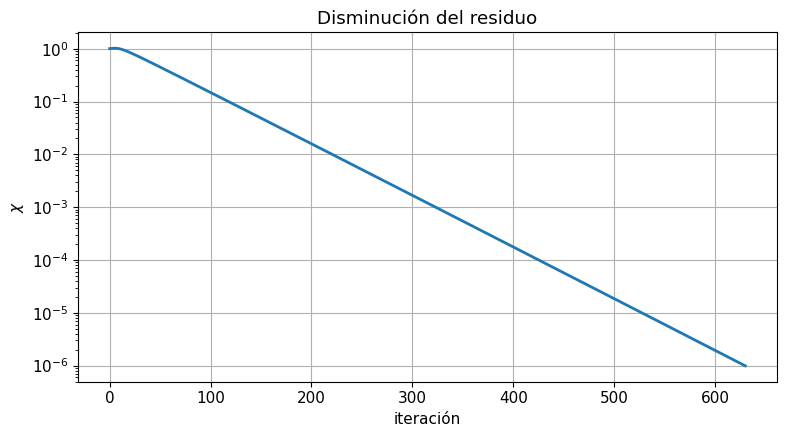

In [13]:
fig, ax = plt.subplots()
ax.semilogy(historia, linewidth=2)
ax.set(
    xlabel="iteración",
    ylabel=r"$\chi$",
    title="Disminución del residuo",
)
fig.tight_layout()
plt.show()

## 8. ¿Qué campo hemos calculado?

La matriz `VX[i, j]` contiene la aproximación de $v_x(x_i,y_j)$. Como elegimos
un flujo completamente desarrollado, esperamos que las columnas sean casi
iguales: el perfil cambia con $y$, pero no con $x$.

Primero veremos todo el campo. Después extraeremos una sección y la
compararemos con Poiseuille.

### Primero leer el campo, después juzgarlo

El mapa permite reconocer la forma general: velocidad nula en las placas y
mayor velocidad hacia el centro. No demuestra por sí solo que la solución sea
correcta; para eso usaremos el perfil analítico, el residuo y la divergencia.

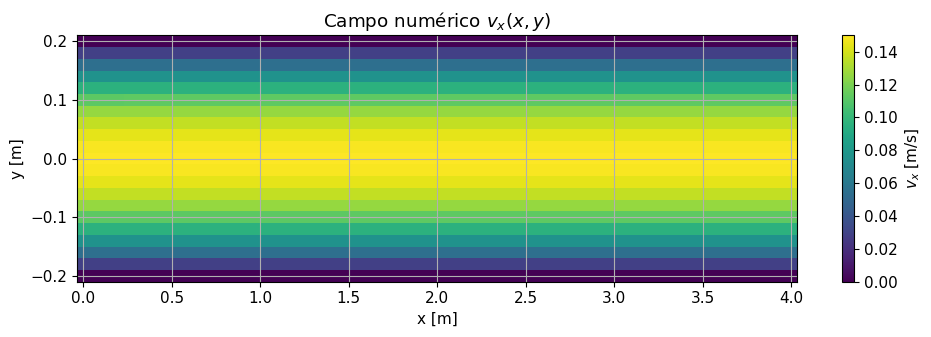

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))
imagen = ax.pcolormesh(X, Y, VX, shading="auto", cmap="viridis")
ax.set(
    xlabel="x [m]",
    ylabel="y [m]",
    title=r"Campo numérico $v_x(x,y)$",
)
fig.colorbar(imagen, ax=ax, label=r"$v_x$ [m/s]")
fig.tight_layout()
plt.show()

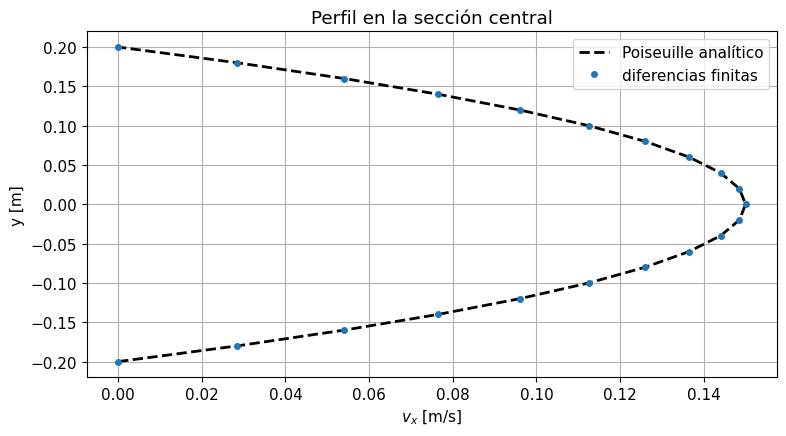

Error máximo respecto a Poiseuille: 9.328e-08 m/s


In [15]:
perfil_numerico = VX[Nx // 2, :]
perfil_referencia = (dp_dx / (2 * rho * nu)) * (ys_num**2 - a**2)

fig, ax = plt.subplots()
ax.plot(
    perfil_referencia,
    ys_num,
    "k--",
    linewidth=2,
    label="Poiseuille analítico",
)
ax.plot(
    perfil_numerico,
    ys_num,
    "o",
    markersize=4,
    label="diferencias finitas",
)
ax.set(
    xlabel=r"$v_x$ [m/s]",
    ylabel="y [m]",
    title="Perfil en la sección central",
)
ax.legend()
fig.tight_layout()
plt.show()

error_maximo = np.max(np.abs(perfil_numerico - perfil_referencia))
print(f"Error máximo respecto a Poiseuille: {error_maximo:.3e} m/s")

La comparación reúne dos pruebas diferentes. El residuo pequeño
indica que la ecuación discretizada se satisface; el error frente a Poiseuille
indica que la discretización y las fronteras representan bien este caso físico.

Por eso no debemos sustituir una medida por la otra.

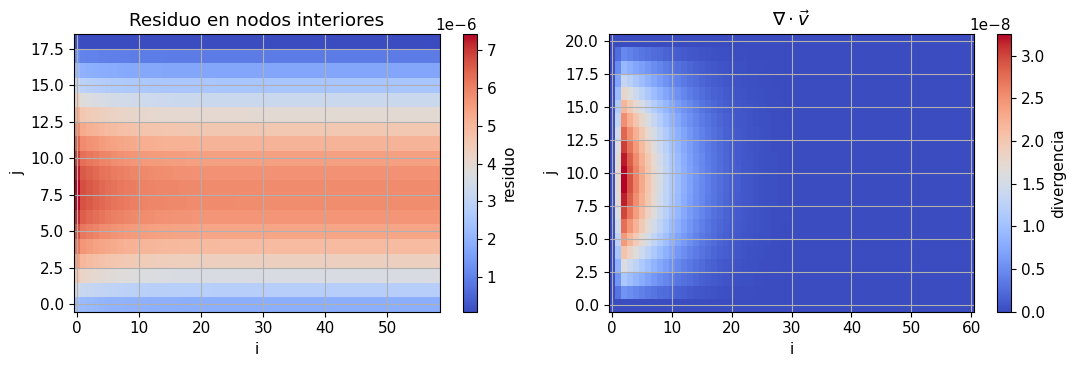

Máximo |residuo| relativo: 9.908e-07
Máxima |divergencia| interior: 3.250e-08


In [16]:
# Comprobamos el residuo espacial y la condición de incomprensibilidad.
residuo_final = residuo_poisson(VX, dx, dy, S)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

imagen_residuo = axes[0].imshow(
    residuo_final.T,
    origin="lower",
    aspect="auto",
    cmap="coolwarm",
)
axes[0].set(
    title="Residuo en nodos interiores",
    xlabel="i",
    ylabel="j",
)
fig.colorbar(imagen_residuo, ax=axes[0], label="residuo")

VY = np.zeros_like(VX)
divergencia = np.zeros_like(VX)
divergencia[1:-1, 1:-1] = (
    (VX[2:, 1:-1] - VX[:-2, 1:-1]) / (2 * dx)
    + (VY[1:-1, 2:] - VY[1:-1, :-2]) / (2 * dy)
)
imagen_divergencia = axes[1].imshow(
    divergencia.T,
    origin="lower",
    aspect="auto",
    cmap="coolwarm",
)
axes[1].set(title=r"$\nabla\cdot\vec v$", xlabel="i", ylabel="j")
fig.colorbar(imagen_divergencia, ax=axes[1], label="divergencia")
fig.tight_layout()
plt.show()

print(f"Máximo |residuo| relativo: {historia[-1]:.3e}")
print(
    "Máxima |divergencia| interior: "
    f"{np.max(np.abs(divergencia[1:-1, 1:-1])):.3e}"
)

## 9. ¿Qué parte de Navier–Stokes estamos resolviendo?

En un flujo general tendríamos que resolver las dos componentes de velocidad,
la advección y la restricción de incomprensibilidad. En este ejemplo no
aparecen en el algoritmo porque hemos elegido

$$
v_y=0,\qquad \frac{\partial v_x}{\partial x}=0,
\qquad \frac{\partial p}{\partial y}=0.
$$

Con esas hipótesis, la advección es nula y la ecuación de cantidad de
movimiento se reduce a difusión viscosa equilibrada por el gradiente de
presión. Esta simplificación es deliberada: permite ver cómo se discretiza y se
resuelve una ecuación antes de introducir un algoritmo acoplado para presión y
velocidad.

In [17]:
# En el caso base, el término convectivo es nulo porque VX no cambia con x.
d_vx_dx = np.zeros_like(VX)
d_vx_dx[1:-1, 1:-1] = (
    (VX[2:, 1:-1] - VX[:-2, 1:-1]) / (2 * dx)
)

adveccion_x = VX * d_vx_dx
print(f"Máximo |dv_x/dx|: {np.max(np.abs(d_vx_dx)):.3e}")
print(f"Máximo |v_x dv_x/dx|: {np.max(np.abs(adveccion_x)):.3e}")

Máximo |dv_x/dx|: 3.250e-08
Máximo |v_x dv_x/dx|: 4.876e-09


## 10. ¿Qué cambia al modificar la relajación?

El parámetro $\omega$ no cambia la ecuación física: cambia la forma de acercarse
a la solución numérica. Usaremos una malla más pequeña para que el control
responda rápidamente. Observa tanto la curva frente a Poiseuille como el número
de iteraciones necesarias.

In [18]:
try:
    from ipywidgets import FloatSlider, interact

    def explorar_omega(omega=1.0):
        """Muestra cómo la relajación cambia la convergencia."""
        _, ys_demo, U_demo, historia_demo = resolver_canal(
            Nx=31,
            Ny=15,
            L=L,
            a=a,
            S=S,
            omega=omega,
            tolerancia=1e-5,
            max_iter=1200,
        )
        perfil_demo = U_demo[U_demo.shape[0] // 2, :]
        referencia_demo = (dp_dx / (2 * rho * nu)) * (ys_demo**2 - a**2)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
        axes[0].plot(perfil_demo, ys_demo, "o", label="numérico")
        axes[0].plot(referencia_demo, ys_demo, "k--", label="analítico")
        axes[0].set(
            xlabel=r"$v_x$ [m/s]",
            ylabel="y [m]",
            title=f"relajación $\\omega$ = {omega:.2f}",
        )
        axes[0].legend()
        axes[1].semilogy(historia_demo)
        axes[1].set(
            xlabel="iteración",
            ylabel=r"$\\chi$",
            title=f"pasos: {len(historia_demo)}",
        )
        fig.tight_layout()
        plt.show()

    interact(
        explorar_omega,
        omega=FloatSlider(
            value=1.0,
            min=0.3,
            max=1.8,
            step=0.1,
            description="relajación",
        ),
    )
except ImportError:
    print("Instala ipywidgets si quieres activar el slider.")

ValueError: 
$\\chi$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1000x350 with 2 Axes>

interactive(children=(FloatSlider(value=1.0, description='relajación', max=1.8, min=0.3), Output()), _dom_clas…

### Reto 2 — invertir el gradiente de presión

Modifica el signo de $\partial p/\partial x$ y ejecuta de nuevo el solver.
Comprueba computacionalmente:

1. hacia dónde apunta ahora la velocidad;
2. si la velocidad máxima conserva aproximadamente su magnitud;
3. si el perfil sigue siendo parabólico.

La respuesta sugerida queda debajo, dentro de un desplegable.

### Qué deberías observar

Al invertir el gradiente de presión cambia el signo de $S$ y, por tanto, el
signo de $v_x$. La forma parabólica se conserva porque la ecuación y las
condiciones de las placas no cambiaron; solo invertimos la causa que impulsa el
flujo.

<details>
<summary>Respuesta sugerida del Reto 2</summary>

```python
dp_dx_reto = -dp_dx
S_reto = dp_dx_reto / (rho * nu)

_, ys_reto, VX_reto, historia_reto = resolver_canal(
    Nx=Nx,
    Ny=Ny,
    L=L,
    a=a,
    S=S_reto,
    omega=1.0,
    tolerancia=1e-6,
    max_iter=8000,
)

perfil_reto = VX_reto[Nx // 2, :]
print(f"gradiente original = {dp_dx:.3f} Pa/m")
print(f"gradiente nuevo    = {dp_dx_reto:.3f} Pa/m")
print(f"velocidad máxima nueva = {perfil_reto.max():.4f} m/s")
```
</details>

## Tarea final — resolución, relajación y malla

Compara tres resoluciones de malla y dos valores de $\omega$. Para cada caso
registra el número de iteraciones, el residuo final y el error máximo frente al
perfil analítico.

Antes de abrir la respuesta, intenta anticipar qué ocurrirá: una malla más fina
representa mejor el perfil, mientras que $\omega$ controla la rapidez de la
relajación. El residuo y el error de discretización no tienen por qué disminuir
de la misma manera.

<details>
<summary>Una posible solución de la tarea final</summary>

```python
resultados = []

for Nx_tarea, Ny_tarea in [(31, 11), (61, 21), (91, 31)]:
    for omega_tarea in [0.7, 1.0]:
        xs_tarea, ys_tarea, U_tarea, hist_tarea = resolver_canal(
            Nx=Nx_tarea,
            Ny=Ny_tarea,
            L=L,
            a=a,
            S=S,
            omega=omega_tarea,
            tolerancia=1e-6,
            max_iter=8000,
        )
        referencia_tarea = (
            dp_dx / (2 * rho * nu) * (ys_tarea**2 - a**2)
        )
        perfil_tarea = U_tarea[Nx_tarea // 2, :]
        error_tarea = np.max(
            np.abs(perfil_tarea - referencia_tarea)
        )
        resultados.append(
            (
                Nx_tarea,
                Ny_tarea,
                omega_tarea,
                len(hist_tarea),
                hist_tarea[-1],
                error_tarea,
            )
        )

print(" Nx   Ny   omega   iteraciones   residuo final   error máximo")
for resultado in resultados:
    print(
        f"{resultado[0]:3d} {resultado[1]:4d} "
        f"{resultado[2]:5.2f} {resultado[3]:12d} "
        f"{resultado[4]:14.3e} {resultado[5]:14.3e}"
    )
```

La lectura esperada es que la resolución espacial y la estrategia de relajación
afectan medidas distintas: la primera cambia la representación del perfil y la
segunda cambia la rapidez con que llegamos a una solución convergida.
</details>